In [1]:
from sklearn.preprocessing import (
 RobustScaler, QuantileTransformer,
 
)
from sklearn.ensemble import IsolationForest
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [8]:
import pandas as pd

data = pd.read_csv('Train.csv')
data2 = pd.read_csv('data2 (1).csv')

In [3]:
temp = data[['Weight_in_gms', 'Cost_of_the_Product', 'Discount_offered']].fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
yt = iso.fit_predict(temp)


m = yt != -1
clean = data[m]
print(f"Removed {len(data) - len(clean)} outlier rows using Isolation Forest.")

Removed 550 outlier rows using Isolation Forest.


In [4]:
r_scalar = RobustScaler()
df_robust = r_scalar.fit_transform(data[['Discount_offered']])
print("Robust Scale discount (First 5):\n",df_robust[:5].flatten())

Robust Scale discount (First 5):
 [6.16666667 8.66666667 6.83333333 0.5        6.5       ]


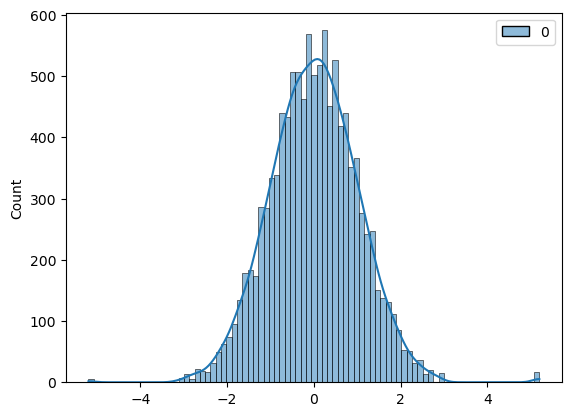

In [5]:
q_trans = QuantileTransformer(output_distribution='normal',random_state=42)
df_quantile = q_trans.fit_transform(data[['Cost_of_the_Product']])
sns.histplot(df_quantile,kde=True)
plt.show()

In [12]:
print(data2.columns)

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')


In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class RareLabelEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, tol=0.05, replace_with='Other'):
        self.tol = tol
        self.replace_with = replace_with
        self.frequent_labels_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            freqs = X[col].value_counts(normalize=True)
            self.frequent_labels_[col] = freqs[freqs >= self.tol].index.tolist()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.frequent_labels_:
            X_copy[col] = np.where(
                X_copy[col].isin(self.frequent_labels_[col]),
                X_copy[col],
                self.replace_with
            )
        return X_copy


rare_imputer = RareLabelEncoder(tol=0.10)

df_rare = rare_imputer.fit_transform(
    data2[['Product_importance','Mode_of_Shipment']]
)

print(
    f"Unique shipment modes before: {data2['Mode_of_Shipment'].nunique()}, "
    f"After: {df_rare['Mode_of_Shipment'].nunique()}"
)

print(df_rare['Mode_of_Shipment'])

Unique shipment modes before: 3, After: 3
0        Flight
1        Flight
2        Flight
3        Flight
4        Flight
          ...  
10994      Ship
10995      Ship
10996      Ship
10997      Ship
10998      Ship
Name: Mode_of_Shipment, Length: 10999, dtype: object
